In [210]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [211]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [212]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [213]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [214]:
X = df.drop(columns=['Outcome'])
y = df['Outcome']

In [215]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [216]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [217]:
# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


In [218]:
# Define the neural network model
class DiabetesModel(nn.Module):
    def __init__(self):
        super(DiabetesModel, self).__init__()
        self.layer1 = nn.Linear(8, 16)
        self.layer2 = nn.Linear(16, 8)
        self.output = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = self.sigmoid(self.output(x))
        return x

model = DiabetesModel()

In [219]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
losses=[]

In [220]:
# Training loop
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f'Epoch {epoch + 1}, Loss: {loss.item():.4f}')

Epoch 1, Loss: 0.6996
Epoch 2, Loss: 0.6901
Epoch 3, Loss: 0.6819
Epoch 4, Loss: 0.6741
Epoch 5, Loss: 0.6664
Epoch 6, Loss: 0.6585
Epoch 7, Loss: 0.6501
Epoch 8, Loss: 0.6410
Epoch 9, Loss: 0.6310
Epoch 10, Loss: 0.6199
Epoch 11, Loss: 0.6077
Epoch 12, Loss: 0.5946
Epoch 13, Loss: 0.5808
Epoch 14, Loss: 0.5667
Epoch 15, Loss: 0.5527
Epoch 16, Loss: 0.5393
Epoch 17, Loss: 0.5270
Epoch 18, Loss: 0.5160
Epoch 19, Loss: 0.5064
Epoch 20, Loss: 0.4986
Epoch 21, Loss: 0.4924
Epoch 22, Loss: 0.4874
Epoch 23, Loss: 0.4834
Epoch 24, Loss: 0.4799
Epoch 25, Loss: 0.4766
Epoch 26, Loss: 0.4730
Epoch 27, Loss: 0.4691
Epoch 28, Loss: 0.4651
Epoch 29, Loss: 0.4610
Epoch 30, Loss: 0.4571
Epoch 31, Loss: 0.4534
Epoch 32, Loss: 0.4502
Epoch 33, Loss: 0.4474
Epoch 34, Loss: 0.4450
Epoch 35, Loss: 0.4429
Epoch 36, Loss: 0.4410
Epoch 37, Loss: 0.4393
Epoch 38, Loss: 0.4377
Epoch 39, Loss: 0.4361
Epoch 40, Loss: 0.4343
Epoch 41, Loss: 0.4325
Epoch 42, Loss: 0.4306
Epoch 43, Loss: 0.4286
Epoch 44, Loss: 0.42

Text(0.5, 1.0, 'Training Loss')

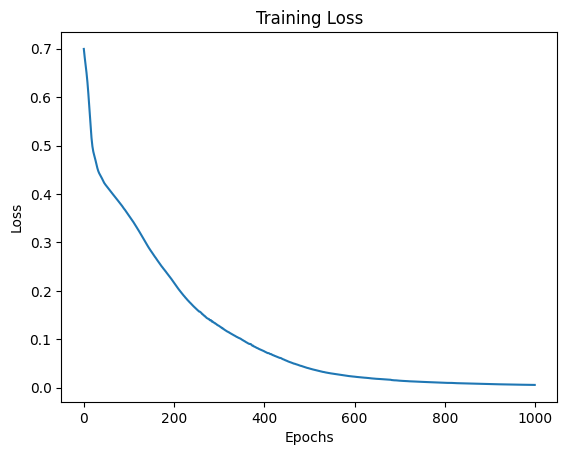

In [221]:
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')

In [222]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    y_pred_cls = y_pred.round()

# Calculate accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test_tensor, y_pred_cls)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.7143


In [223]:
# Example new data point
new_data = torch.tensor([[6, 148, 72, 35, 0, 33.6, 0.627, 50]], dtype=torch.float32)
new_data_scaled = scaler.transform(new_data)
new_data_tensor = torch.tensor(new_data_scaled, dtype=torch.float32)

# Make prediction
model.eval()
with torch.no_grad():
    prediction = model(new_data_tensor)
    predicted_class = prediction.round().item()
    print(f'Predicted class: {int(predicted_class)}')

Predicted class: 1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
